# Single-TCR Model Proteome Predictions

Loads proteome (`netmhc_WBSB_9mers_clean.csv`) predictions from each TCR's `prediction/` directory, scores ROC / PR curves against `data/activation_binary.csv` as ground truth, then filters predictions for 9mers with P8 = Proline.

In [16]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.colors import to_hex
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [17]:
# Order shown in the reference figure
TCR_ORDER = [
    '4.1', '4.2', '4.3', '4.4',
    '8.4', '9.1',
    '19.2',
    '26.1', '26.2', '28.1',
    '135.1', '135.3', '135.4', '135.7', '135.8',
    '019.1',
]

REPO_DIR = os.path.abspath('..')
PROTEOME_PATH = os.path.join(REPO_DIR, 'data/netmhc_WBSB_9mers_clean.csv')
TRUTH_PATH = os.path.join(REPO_DIR, 'data/activation_binary.csv')
PRED_TEMPLATE = os.path.join(
    REPO_DIR, 'model_outputs/single_tcr/lightning_logs/{tcr}_finetune_esm/outputs/y_pred_proteome.npy'
)

In [18]:
proteome = pd.read_csv(PROTEOME_PATH)
proteome = proteome.loc[~proteome['Epitope'].str.contains('X')].reset_index(drop=True)

# attach proteome scores per TCR (skip TCRs without a prediction file yet)
available_tcrs = []
for tcr in TCR_ORDER:
    path = PRED_TEMPLATE.format(tcr=tcr)
    if not os.path.exists(path):
        print(f'skip {tcr}: prediction file not found')
        continue
    logits = np.load(path).reshape(-1)
    assert len(logits) == len(proteome), (
        f'length mismatch for {tcr}: pred={len(logits)} vs proteome={len(proteome)}'
    )
    proteome[f'{tcr}_Scores'] = sigmoid(logits)
    available_tcrs.append(tcr)

truth = pd.read_csv(TRUTH_PATH)

# restrict to peptides with ground-truth labels in activation_binary.csv
scored = proteome.merge(truth, left_on='Epitope', right_on='Peptide', how='inner')
scored.shape, available_tcrs

((15, 42),
 ['4.1',
  '4.2',
  '4.3',
  '4.4',
  '8.4',
  '9.1',
  '19.2',
  '26.1',
  '26.2',
  '28.1',
  '135.1',
  '135.3',
  '135.4',
  '135.7',
  '135.8',
  '019.1'])

/var/tmp/pbs.7147756.polaris-pbs-01.hsn.cm.polaris.alcf.anl.gov/ipykernel_1318625/173021060.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mean_color = to_hex(cm.get_cmap('coolwarm')(0.85))


skip 4.1: only one class present in ground truth
4.2: AUROC = 0.857  AP = 0.333  (positives = 1/15)
4.3: AUROC = 0.722  AP = 0.554  (positives = 3/15)
skip 4.4: only one class present in ground truth
8.4: AUROC = 0.857  AP = 0.333  (positives = 1/15)
9.1: AUROC = 0.808  AP = 0.643  (positives = 2/15)
19.2: AUROC = 0.680  AP = 0.566  (positives = 5/15)
26.1: AUROC = 0.786  AP = 0.250  (positives = 1/15)
26.2: AUROC = 0.929  AP = 0.500  (positives = 1/15)
28.1: AUROC = 0.214  AP = 0.083  (positives = 1/15)
135.1: AUROC = 0.667  AP = 0.528  (positives = 3/15)
135.3: AUROC = 0.769  AP = 0.625  (positives = 2/15)
135.4: AUROC = 0.786  AP = 0.250  (positives = 1/15)
skip 135.7: only one class present in ground truth
135.8: AUROC = 0.889  AP = 0.700  (positives = 3/15)
019.1: AUROC = 0.429  AP = 0.111  (positives = 1/15)

Mean across 13 TCRs: AUROC = 0.722 ± 0.191   AP = 0.421 ± 0.198


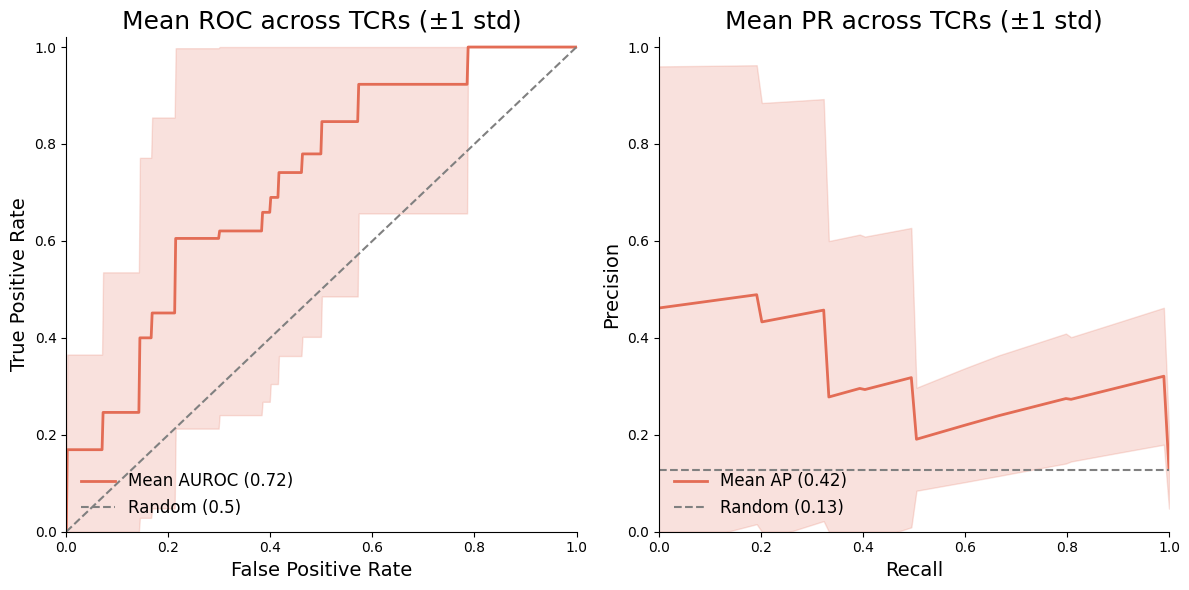

In [19]:
mean_color = to_hex(cm.get_cmap('coolwarm')(0.85))

mean_fpr = np.linspace(0, 1, 500)
mean_recall = np.linspace(0, 1, 100)
tprs, aucs, precisions, aps, prevalences = [], [], [], [], []

for tcr in available_tcrs:
    if tcr not in scored.columns:
        continue
    y_true = scored[tcr].to_numpy().astype(int)
    y_score = scored[f'{tcr}_Scores'].to_numpy()
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        print(f'skip {tcr}: only one class present in ground truth')
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(roc_auc)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)
    aps.append(ap)
    prevalences.append(y_true.mean())

    print(f'{tcr}: AUROC = {roc_auc:.3f}  AP = {ap:.3f}  (positives = {int(y_true.sum())}/{len(y_true)})')

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = float(np.mean(aucs))
std_auc = float(np.std(aucs))

mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
mean_ap = float(np.mean(aps))
std_ap = float(np.std(aps))

print(f'\nMean across {len(aucs)} TCRs: AUROC = {mean_auc:.3f} ± {std_auc:.3f}   AP = {mean_ap:.3f} ± {std_ap:.3f}')

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

ax_roc.plot(mean_fpr, mean_tpr, color=mean_color, lw=2,
            label=f'Mean AUROC ({mean_auc:.2f})')
ax_roc.fill_between(mean_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    color=mean_color, alpha=0.2)
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (0.5)')

ax_pr.plot(mean_recall, mean_precision, color=mean_color, lw=2,
           label=f'Mean AP ({mean_ap:.2f})')
ax_pr.fill_between(mean_recall,
                   np.clip(mean_precision - std_precision, 0, 1),
                   np.clip(mean_precision + std_precision, 0, 1),
                   color=mean_color, alpha=0.2)
pr_baseline = float(np.mean(prevalences)) if prevalences else 0.0
ax_pr.plot([0, 1], [pr_baseline, pr_baseline], linestyle='--', color='gray',
           label=f'Random ({pr_baseline:.2f})')

for ax, title, xlabel, ylabel in [
    (ax_roc, 'Mean ROC across TCRs (±1 std)', 'False Positive Rate', 'True Positive Rate'),
    (ax_pr, 'Mean PR across TCRs (±1 std)', 'Recall', 'Precision'),
]:
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

## TCR 19.2 variants (C1–C5)

Same proteome ROC / PR analysis restricted to TCR 19.2 and its C1–C5 variants. The variant prediction files live at `outputs/y_pred_proteome.npy` (not the `prediction/` path used above), and `data/activation_binary.csv` already has columns for `19.2C1`…`19.2C5`, so this section is self-contained — no dependency on the cells above.

In [20]:
VARIANT_ORDER = ['19.2', '19.2C1', '19.2C2', '19.2C3', '19.2C4', '19.2C5']
VARIANT_PRED_TEMPLATE = os.path.join(
    REPO_DIR, 'model_outputs/single_tcr/lightning_logs/{tcr}_finetune_esm/outputs/y_pred_proteome.npy'
)

variant_proteome = pd.read_csv(PROTEOME_PATH)
variant_proteome = variant_proteome.loc[~variant_proteome['Epitope'].str.contains('X')].reset_index(drop=True)
variant_truth = pd.read_csv(TRUTH_PATH)

for tcr in VARIANT_ORDER:
    logits = np.load(VARIANT_PRED_TEMPLATE.format(tcr=tcr)).reshape(-1)
    assert len(logits) == len(variant_proteome), (
        f'length mismatch for {tcr}: pred={len(logits)} vs proteome={len(variant_proteome)}'
    )
    variant_proteome[f'{tcr}_Scores'] = sigmoid(logits)

variant_scored = variant_proteome.merge(variant_truth, left_on='Epitope', right_on='Peptide', how='inner')
variant_scored.shape, VARIANT_ORDER

((15, 32), ['19.2', '19.2C1', '19.2C2', '19.2C3', '19.2C4', '19.2C5'])

/var/tmp/pbs.7147756.polaris-pbs-01.hsn.cm.polaris.alcf.anl.gov/ipykernel_1318625/3668041917.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mean_color = to_hex(cm.get_cmap('coolwarm')(0.85))


19.2: AUROC = 0.680  AP = 0.566  (positives = 5/15)
19.2C1: AUROC = 0.714  AP = 0.816  (positives = 8/15)
19.2C2: AUROC = 0.667  AP = 0.621  (positives = 6/15)
19.2C3: AUROC = 0.907  AP = 0.818  (positives = 6/15)
19.2C4: AUROC = 0.429  AP = 0.111  (positives = 1/15)
19.2C5: AUROC = 0.472  AP = 0.234  (positives = 3/15)

Mean across 6 variants: AUROC = 0.645 ± 0.159   AP = 0.528 ± 0.270


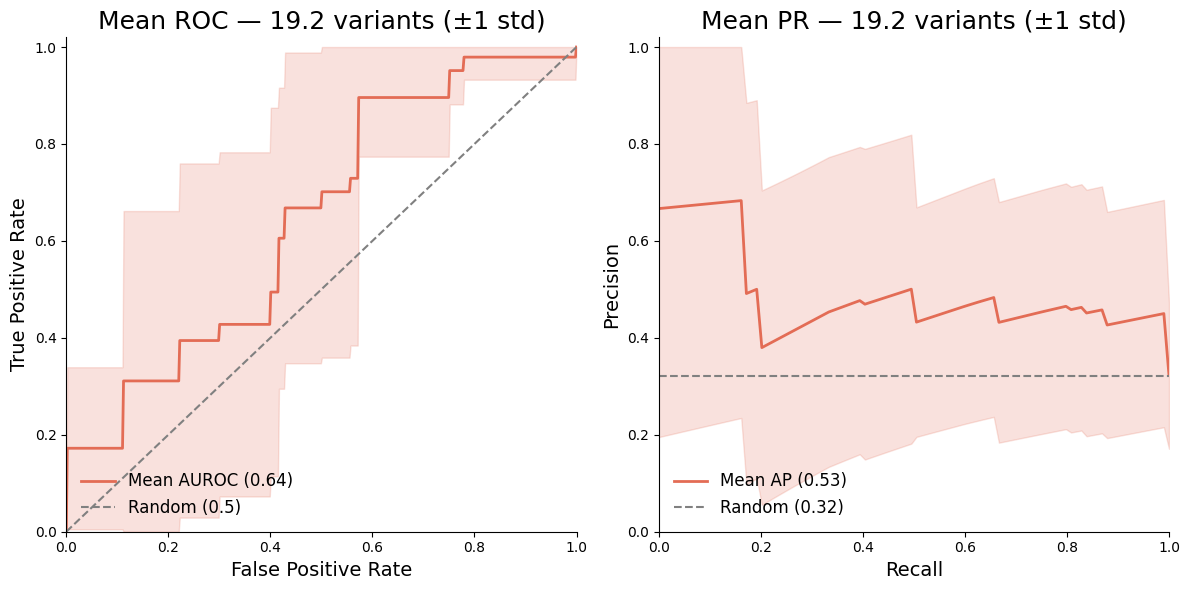

In [21]:
mean_color = to_hex(cm.get_cmap('coolwarm')(0.85))

mean_fpr = np.linspace(0, 1, 500)
mean_recall = np.linspace(0, 1, 100)
tprs, aucs, precisions, aps = [], [], [], []

for tcr in VARIANT_ORDER:
    if tcr not in variant_scored.columns:
        print(f'skip {tcr}: no truth column in activation_binary.csv')
        continue
    y_true = variant_scored[tcr].to_numpy().astype(int)
    y_score = variant_scored[f'{tcr}_Scores'].to_numpy()
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        print(f'skip {tcr}: only one class present in ground truth')
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(roc_auc)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)
    aps.append(ap)

    print(f'{tcr}: AUROC = {roc_auc:.3f}  AP = {ap:.3f}  (positives = {int(y_true.sum())}/{len(y_true)})')

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = float(np.mean(aucs))
std_auc = float(np.std(aucs))

mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
mean_ap = float(np.mean(aps))
std_ap = float(np.std(aps))

print(f'\nMean across {len(aucs)} variants: AUROC = {mean_auc:.3f} ± {std_auc:.3f}   AP = {mean_ap:.3f} ± {std_ap:.3f}')

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

ax_roc.plot(mean_fpr, mean_tpr, color=mean_color, lw=2,
            label=f'Mean AUROC ({mean_auc:.2f})')
ax_roc.fill_between(mean_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    color=mean_color, alpha=0.2)
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (0.5)')

ax_pr.plot(mean_recall, mean_precision, color=mean_color, lw=2,
           label=f'Mean AP ({mean_ap:.2f})')
ax_pr.fill_between(mean_recall,
                   np.clip(mean_precision - std_precision, 0, 1),
                   np.clip(mean_precision + std_precision, 0, 1),
                   color=mean_color, alpha=0.2)
pr_baseline = float(np.mean([variant_scored[t].astype(int).mean()
                             for t in VARIANT_ORDER if t in variant_scored.columns]))
ax_pr.plot([0, 1], [pr_baseline, pr_baseline], linestyle='--', color='gray',
           label=f'Random ({pr_baseline:.2f})')

for ax, title, xlabel, ylabel in [
    (ax_roc, 'Mean ROC — 19.2 variants (±1 std)', 'False Positive Rate', 'True Positive Rate'),
    (ax_pr, 'Mean PR — 19.2 variants (±1 std)', 'Recall', 'Precision'),
]:
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

## Filter Predictions

Single configurable cell to slice and rank proteome predictions across all TCRs (`TCR_ORDER` + `VARIANT_ORDER`). Edit the controls at the top of the cell, then re-run.

- **`SORT_BY_TCR`** — which TCR's score column to sort by (descending). Available TCRs are printed by the cell.
- **`BINDING_FILTER`** — `'WB'`, `'SB'`, or `None` for both.
- **`P8_PROLINE_ONLY`** — restrict to 9mers with proline at position 8.
- **`TOP_N`** — number of top peptides to print.

In [22]:
# --- Controls (edit and re-run) ---
SORT_BY_TCR     = '19.2'    # any TCR from the available list printed below
BINDING_FILTER  = None      # None | 'WB' | 'SB'
P8_PROLINE_ONLY = False     # restrict to 9mers with P at position 8
TOP_N           = 20

# --- Load proteome and attach scores from outputs/y_pred_proteome.npy ---
ALL_TCRS = list(dict.fromkeys(TCR_ORDER + VARIANT_ORDER))  # dedupe, preserve order
FILTER_PRED_TEMPLATE = os.path.join(
    REPO_DIR, 'model_outputs/single_tcr/lightning_logs/{tcr}_finetune_esm/outputs/y_pred_proteome.npy'
)

filter_proteome = pd.read_csv(PROTEOME_PATH)
filter_proteome = filter_proteome.loc[~filter_proteome['Epitope'].str.contains('X')].reset_index(drop=True)

available = []
for tcr in ALL_TCRS:
    p = FILTER_PRED_TEMPLATE.format(tcr=tcr)
    if not os.path.exists(p):
        continue
    logits = np.load(p).reshape(-1)
    if len(logits) != len(filter_proteome):
        print(f'skip {tcr}: pred={len(logits)} vs proteome={len(filter_proteome)}')
        continue
    filter_proteome[f'{tcr}_Scores'] = sigmoid(logits)
    available.append(tcr)

print(f'TCRs with predictions ({len(available)}): {available}')

# --- Apply filters ---
assert BINDING_FILTER in (None, 'WB', 'SB'), "BINDING_FILTER must be None, 'WB', or 'SB'"
mask = pd.Series(True, index=filter_proteome.index)
if BINDING_FILTER is not None:
    mask &= filter_proteome['Binding'].eq(BINDING_FILTER)
if P8_PROLINE_ONLY:
    mask &= filter_proteome['Epitope'].str.len().eq(9) & filter_proteome['Epitope'].str[-2].eq('P')

filtered = filter_proteome.loc[mask].reset_index(drop=True)
binding_desc = BINDING_FILTER if BINDING_FILTER else 'WB+SB'
p8_desc = 'P8=P' if P8_PROLINE_ONLY else 'all positions'
print(f'After filters ({binding_desc}, {p8_desc}): {len(filtered):,} / {len(filter_proteome):,} peptides')

# --- Sort and display ---
sort_col = f'{SORT_BY_TCR}_Scores'
assert sort_col in filtered.columns, f'{SORT_BY_TCR} not available; choose from {available}'
top = filtered.sort_values(sort_col, ascending=False).head(TOP_N)
print(f'\nTop {TOP_N} peptides by {SORT_BY_TCR} score (descending):')
print(top[['Epitope', 'Binding', sort_col]].to_string(index=False))

TCRs with predictions (21): ['4.1', '4.2', '4.3', '4.4', '8.4', '9.1', '19.2', '26.1', '26.2', '28.1', '135.1', '135.3', '135.4', '135.7', '135.8', '019.1', '19.2C1', '19.2C2', '19.2C3', '19.2C4', '19.2C5']
After filters (WB+SB, all positions): 293,467 / 293,467 peptides

Top 20 peptides by 19.2 score (descending):
  Epitope Binding  19.2_Scores
ARMLLLALF      SB     0.999751
TRLALIAPK      SB     0.999746
VRILLLAAL      SB     0.999691
SKFILIAAY      WB     0.999560
NRVQLLALL      SB     0.999511
GRFVLLAAL      SB     0.999421
GRMLLIAVL      SB     0.999385
SQMAILALF      WB     0.999373
GQIQLIGSF      WB     0.999366
SRAMVLAAF      SB     0.999241
TRVPLLAAI      SB     0.999166
ARALLLAAL      SB     0.999059
AQMLLAASF      WB     0.999031
TRLALLALV      WB     0.998991
SRIPLIALF      SB     0.998973
IRMALLATV      WB     0.998876
KQMNLLAVL      WB     0.998811
ERMVLVAAF      SB     0.998760
QRVVLLAIL      SB     0.998749
GRVFLLSAV      WB     0.998689
